# 패키지 및 데이터

In [27]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb
import shap

from matplotlib import pyplot as plt
from pandas import DataFrame, concat


# ==================================================
# scikit-learn
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    SGDRegressor,
    LogisticRegression,
)


# ==================================================
# 사용자 정의 라이브러리
# ==================================================
from hossam import *


### 데이터

In [2]:
origin = load_data("pima_indians_diabetes_preprocessed")
origin.head()
origin.info()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


# 훈련, 검증 데이터 분리

In [3]:
df = origin.copy()

# 중요!!! 종속변수를 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')
yname = "Outcome"
X = df.drop(columns=[yname])
y = df[yname]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

# 로지스틱 모형 적합

In [4]:
%%time 
%%time

pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
     "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)

gs.fit(X_train, y_train)

estimator = gs.best_estimator_
estimator


CPU times: total: 1.19 s
Wall time: 1.2 s
CPU times: total: 1.19 s
Wall time: 1.2 s


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    random_state=52))])

# SHAP 분석

### SHAP 객체 생성

In [7]:
# pipeline에서 단독 학습 모델 객체 추출
model = estimator.named_steps["model"]

# 훈련 데이터에 대한VIF 선택기와 스케일러 변환 적용
x_vif = estimator.named_steps["VIF_Selector"].transform(X_train)
X_scaled = estimator.named_steps["scaler"].transform(x_vif)

# 훈련 데이터의 스케일된 특징 행렬을 사용하여 SHAP 마스커 생성
masker = shap.maskers.Independent(X_scaled)

# 선형 설명자 생성
explainer = shap.LinearExplainer(model, masker=masker)

# 2.SHAP 값 계산: shape = n [n_samples, n_features]
shap_values = explainer.shap_values(X_scaled)
shap_values

array([[ 0.36637001,  1.19352029, -0.02374752, ...,  0.13558711,
         0.0109997 ,  0.3214378 ],
       [ 0.49955471, -0.66502013,  0.00984162, ...,  1.34818579,
        -0.39504107,  0.25401179],
       [ 0.36637001,  0.19161826, -0.01702969, ..., -0.27607911,
         0.26673056,  0.46305622],
       ...,
       [ 0.0942495 , -0.19673964,  0.01991836, ..., -1.18774282,
        -0.0015263 ,  0.13042584],
       [-0.00905658, -1.44309066,  0.03671293, ..., -1.20308754,
         0.01213369, -0.41599405],
       [ 0.25002199, -0.8945048 ,  0.04343076, ...,  0.2996527 ,
        -0.00381409,  0.2769961 ]])

### SHAP 분석 결과 도출

In [13]:
# 3. DatFrame 변환
shap_df = DataFrame(
    shap_values,
    columns = x_vif.columns,
    index=x_vif.index
)

# 4.요약통계
summary_df = DataFrame(
    {
        "feature":shap_df.columns,
        "mean_abs_shap":shap_df.abs().mean().values,
        "mean_shap":shap_df.mean().values,
        "std_shap":shap_df.std().values
    }
)

# 5.영향 방향(보수적 표현)
summary_df["direction"] = np.where(
    summary_df["mean_shap"] > 0,
    "양(+) 경향",
    np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
)

# 6.변동성 지표
summary_df["cv"] = summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)

# 8.주요 변수 표시(누적80%)
total_importance = summary_df["mean_abs_shap"].sum()
summary_df["importance_ratio"] = summary_df["mean_abs_shap"] / total_importance
summary_df["importance_cumsum"] = summary_df["importance_ratio"].cumsum()

summary_df["is_important"] = np.where(
    summary_df['importance_cumsum'] <= 0.80,
    "core",
    "secondary"
)

summary_df

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,importance_ratio,importance_cumsum,is_important
0,Pregnancies,0.301,-0.048,0.356,음(-) 경향,1.182,0.127,0.127,core
1,Glucose,0.918,-0.039,1.131,음(-) 경향,1.232,0.388,0.515,core
2,BloodPressure,0.031,-0.005,0.040,음(-) 경향,1.298,0.013,0.528,core
3,SkinThickness,0.003,-0.000,0.004,음(-) 경향,1.409,0.001,0.530,core
4,Insulin,0.009,-0.001,0.016,음(-) 경향,1.657,0.004,0.533,core
5,BMI,0.572,0.053,0.708,양(+) 경향,1.236,0.242,0.775,core
6,DiabetesPedigreeFunction,0.254,0.014,0.318,양(+) 경향,1.249,0.108,0.883,secondary
7,Age,0.277,-0.027,0.318,음(-) 경향,1.150,0.117,1.000,secondary


### Summary Plot

> 시각화를 위해 앞에서 추출한 훈련 데이터를 DataFrame으로 구성

In [16]:
X = DataFrame(X_scaled, columns = x_vif.columns, index=x_vif.index)
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
754,1.165,1.091,0.464,0.452,0.007,0.117,-0.010,1.096
558,1.540,-0.554,-0.373,1.144,0.007,1.832,-1.289,0.884
584,1.165,0.205,0.297,-0.432,3.161,-0.465,0.795,1.541
78,-1.696,0.429,-0.038,0.149,0.007,1.507,-0.668,-0.580
193,1.540,0.552,-0.038,0.149,0.007,2.435,0.451,0.734
...,...,...,...,...,...,...,...,...
503,1.012,-0.927,-0.707,-0.307,-0.910,0.249,0.948,0.810
86,1.740,-0.436,-0.038,2.080,0.007,0.705,-1.056,1.096
151,0.400,-0.139,-0.624,0.149,0.007,-1.754,-0.050,0.495
525,0.109,-1.242,-1.042,-1.306,0.007,-1.776,-0.007,-1.224


### 이전코드와 동일

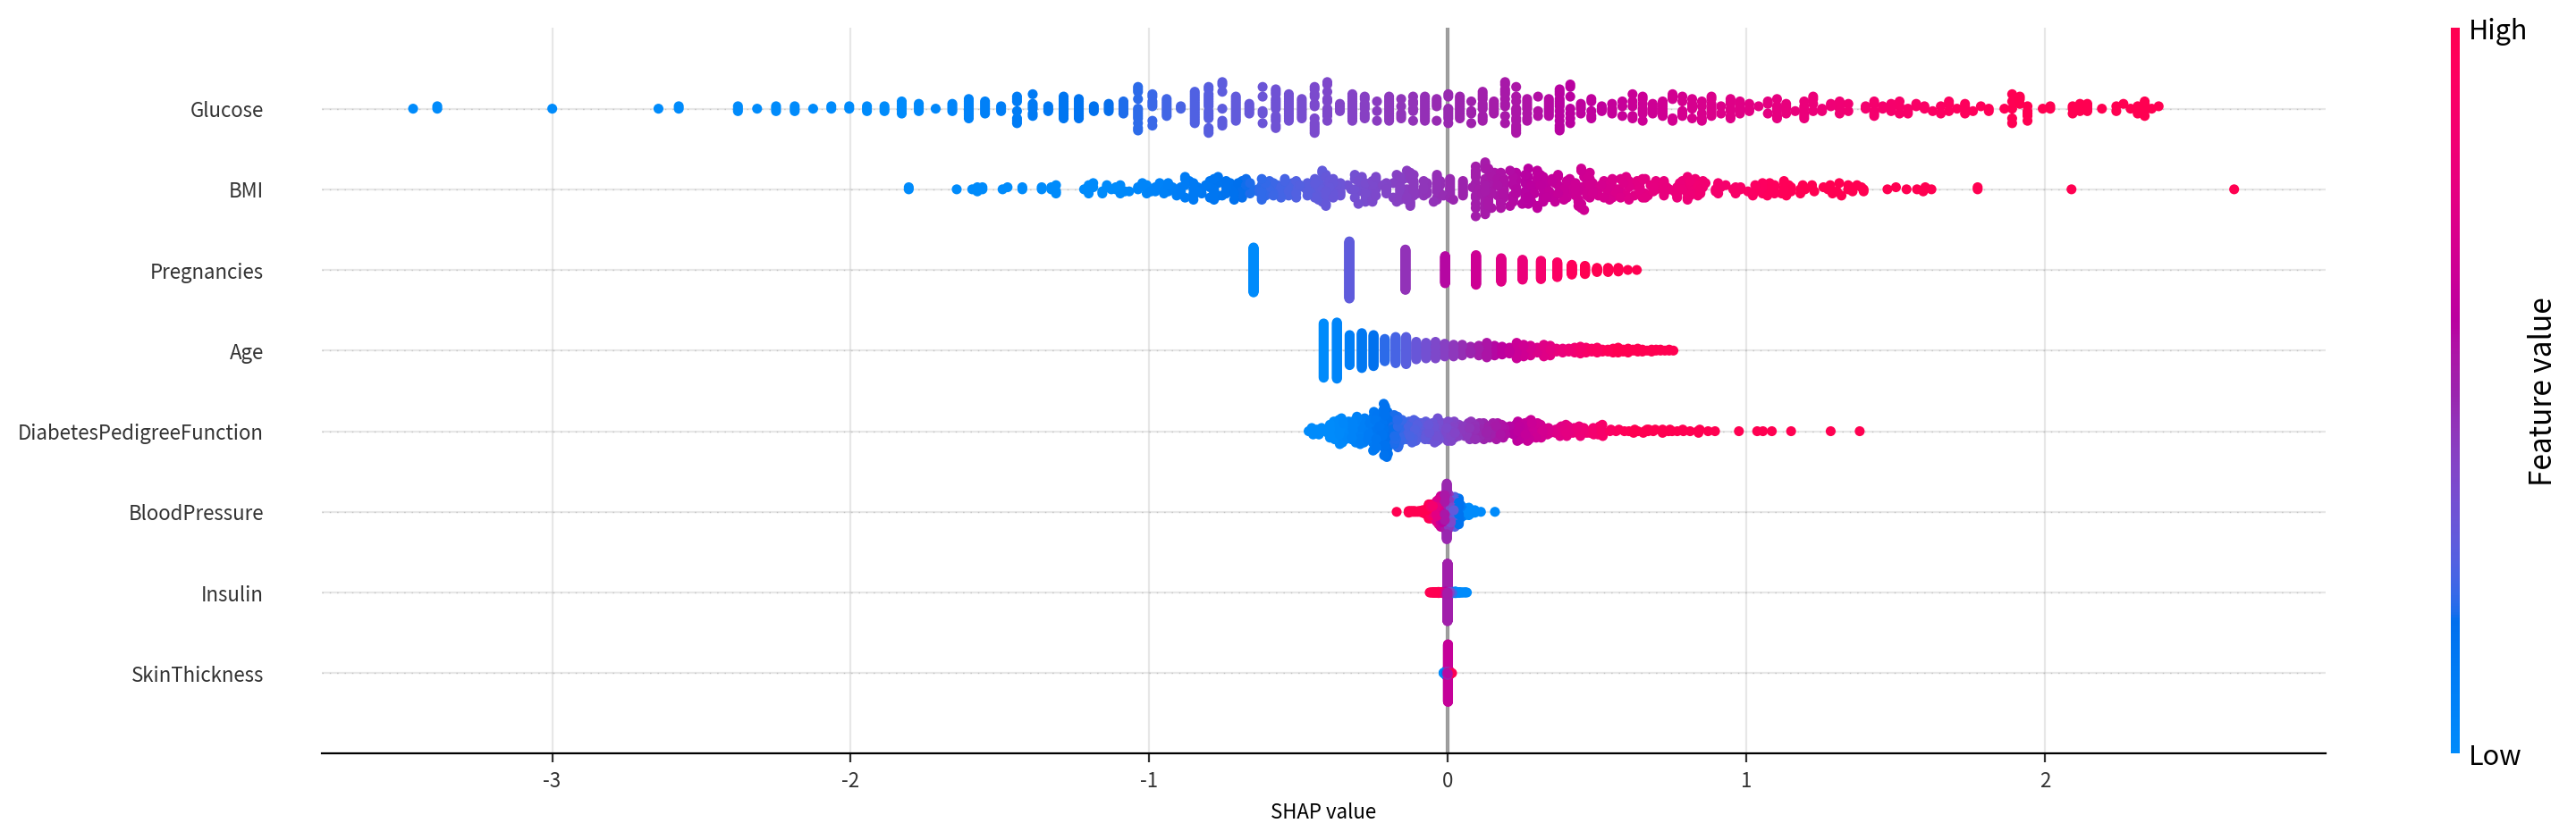

In [17]:
# ===============================
# Figure 설정
# ===============================
width = 1600
my_dpi = 200

shap.summary_plot(
    shap_values,
    X,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(
    width / 100,
    len(summary_df) * 60 / 100
)
fig.set_dpi(my_dpi)

ax = fig.get_axes()[0]


# ===============================
# 그래프 스타일링
# ===============================
ax.grid(True, alpha=0.3)

ax.set_xlabel("SHAP value", fontsize=8)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)


# ===============================
# 출력
# ===============================
plt.tight_layout()
plt.show()
plt.close()


### SHAP 분석 통합 함수

In [28]:
def hs_shap_analysis(
    model,
    X: DataFrame,
    plot: bool = True,
    width: int = 1600,
):
    # ==================================================
    # 1. SHAP 유형 판별 (Pipeline 대응)
    # ==================================================
    if isinstance(model, Pipeline):
        estimator = model.named_steps["model"]
        is_pipeline = True
    else:
        estimator = model
        is_pipeline = False

    # 선형 모델 여부
    is_linear_model = isinstance(
        estimator,
        (LinearRegression, Ridge, Lasso, SGDRegressor, LogisticRegression),
    )

    # 데이터 복사
    X_df = X.copy()
    columns = X.columns.tolist()
    index = X.index.tolist()

    # ==================================================
    # 2. SHAP Explainer 설정
    # ==================================================
    if is_linear_model:
        # Pipeline일 경우 전처리 단계 적용
        if is_pipeline:
            for name, step in model.named_steps.items():
                if name == "model":
                    continue
                X_df = step.transform(X_df)  # type: ignore

        masker = shap.maskers.Independent(X_df)
        explainer = shap.LinearExplainer(estimator, masker=masker)

    else:
        explainer = shap.TreeExplainer(estimator)

    # SHAP 계산
    shap_values = explainer.shap_values(X_df)

    # ==================================================
    # 3. DataFrame 변환
    # ==================================================
    shap_df = DataFrame(
        shap_values,
        columns=columns,
        index=index,
    )

    # ==================================================
    # 4. 요약 통계
    # ==================================================
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # 영향 방향
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(
            summary_df["mean_shap"] < 0,
            "음(-) 경향",
            "혼합/미약",
        ),
    )

    # 변동성 지표
    summary_df["cv"] = (
        summary_df["std_shap"]
        / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",
        "variable",
    )

    # ==================================================
    # 5. 중요도 정렬 및 누적 80%
    # ==================================================
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",
        "secondary",
    )

    # ==================================================
    # 6. 시각화
    # ==================================================
    if plot:
        my_dpi = 200

        shap.summary_plot(
            shap_values,
            X_df,
            show=False,
        )

        fig = plt.gcf()
        fig.set_size_inches(
            width / my_dpi,
            len(summary_df) * 70 / my_dpi,
        )
        fig.set_dpi(my_dpi)

        ax = fig.get_axes()[0]
        ax.set_title("SHAP Summary Plot", fontsize=10, pad=10)
        ax.set_xlabel("SHAP value", fontsize=8)
        ax.grid(True, alpha=0.3)

        ax.tick_params(axis="x", labelsize=6)
        ax.tick_params(axis="y", labelsize=8)

        plt.tight_layout()
        plt.show()
        plt.close()

    return summary_df, shap_values


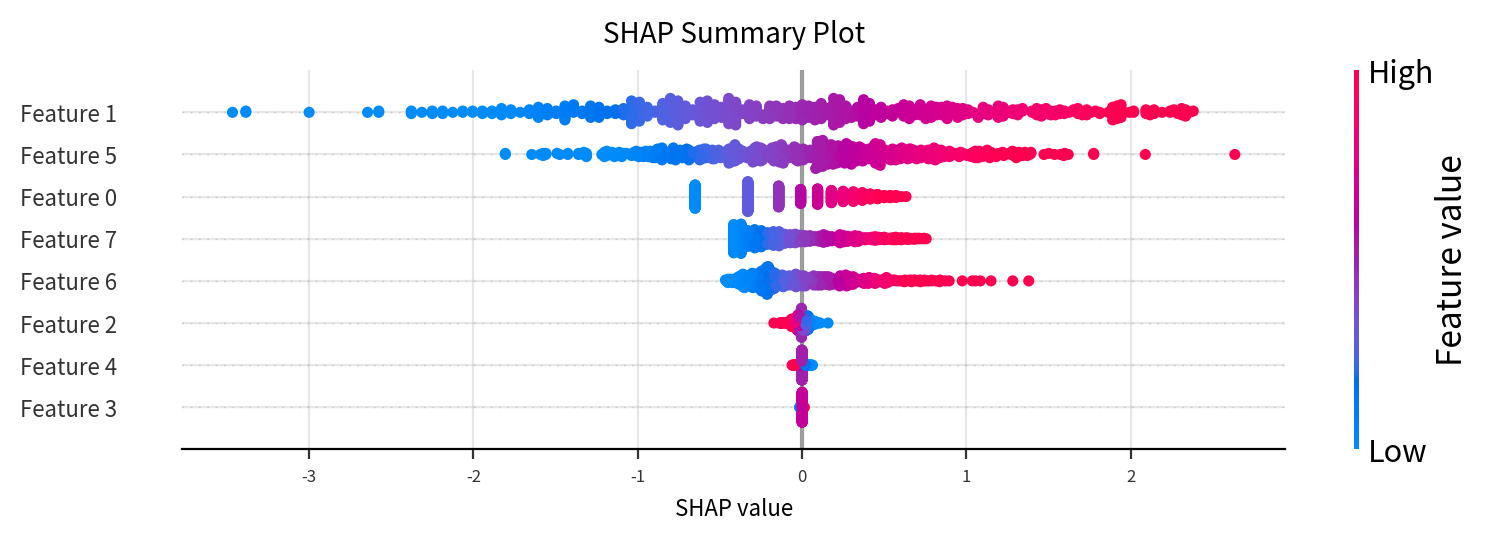

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,Glucose,0.918,-0.039,1.131,음(-) 경향,1.232,variable,0.388,0.388,core
1,BMI,0.572,0.053,0.708,양(+) 경향,1.236,variable,0.242,0.630,core
2,Pregnancies,0.301,-0.048,0.356,음(-) 경향,1.182,variable,0.127,0.757,core
3,Age,0.277,-0.027,0.318,음(-) 경향,1.150,variable,0.117,0.874,secondary
4,DiabetesPedigreeFunction,0.254,0.014,0.318,양(+) 경향,1.249,variable,0.108,0.982,secondary
5,BloodPressure,0.031,-0.005,0.040,음(-) 경향,1.298,variable,0.013,0.995,secondary
6,Insulin,0.009,-0.001,0.016,음(-) 경향,1.657,variable,0.004,0.999,secondary
7,SkinThickness,0.003,-0.000,0.004,음(-) 경향,1.409,variable,0.001,1.000,secondary


array([[ 3.66370005e-01,  1.19352029e+00, -2.37475226e-02,
         1.59167714e-03, -1.06402253e-03,  1.35587113e-01,
         1.09996996e-02,  3.21437797e-01],
       [ 4.99554705e-01, -6.65020126e-01,  9.84161828e-03,
         4.03414454e-03, -1.06402253e-03,  1.34818579e+00,
        -3.95041073e-01,  2.54011794e-01],
       [ 3.66370005e-01,  1.91618259e-01, -1.70296944e-02,
        -1.53230882e-03, -5.00752532e-02, -2.76079114e-01,
         2.66730565e-01,  4.63056225e-01],
       [-6.50852563e-01,  4.45402245e-01, -3.59403808e-03,
         5.19221708e-04, -1.06402253e-03,  1.11793270e+00,
        -1.98046170e-01, -2.11246035e-01],
       [ 4.99554705e-01,  5.84445304e-01, -3.59403808e-03,
         5.19221708e-04, -1.06402253e-03,  1.77434545e+00,
         1.57395283e-01,  2.06394534e-01]])

In [29]:

summary_df, shap_values = hs_shap_analysis(estimator, X_train)
display(summary_df)
display(shap_values[:5])